---
title: "{{< fa cogs >}} Optimisation sous Python"
title-block-banner: true
description: "Exploration approfondie et visualisation élégante de divers problèmes d'optimisation sous {{< fa brands python >}}, en tirant parti des bibliothèques **Numpy**, **Scipy** et **Matplotlib**."
image: "opti_python_file/imgs/val_f_pourtout_R.png"
categories: ["Python", "Jupyter"]
date: "2023-10-01"
author: "Hugo Cochereau et Romain Siette"
format: 
    html:
        css: "../../sections_css/style_projets.css"
---

# Optimisation sous python

# Construction des résultats et des fonctions

## Importation des packages

In [2]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import opti_python_file.Mes_fonctions.Fonction_graphique.Fonction_graphique as fcg
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib import cm
import scipy.optimize as so

sym.init_printing()

## Fonction 


### Fonction calcul des mineurs :

In [2]:
def desmineurs_sympy(H):
    assert np.shape(H)[0] == np.shape(H)[1]
    m = []
    for i in range(1,np.shape(H)[0]+1):
        m.append(sym.det(H[0:i,0:i]))
    return m

### Fonction calcul des gradients et hessienne :

In [3]:
def resolution_Ndim(f, par=None ,valpar=None,ordre_symboles=None ):
    if par is not None:
        assert isinstance(par,list) 
    if valpar is not None:
        assert isinstance(valpar,list) 

    # Permet d'organiser les résultats
    if ordre_symboles !=None:
        variables = ordre_symboles
    else :
        variables = list(f.free_symbols)#[::-1](nécessaire lorsque les free_symbols se lisent à l'envers(dépend des fois))
    
    
    # On isole les parmaètres afin de ne pas les utiliser comme des variables
    if par is not None:
        parametre = []
        for i in par:
            if i != None : parametre.append(variables.pop(i))

    #Substitution des paramètres s'ils prennent une valeur particulière
        if valpar is not None:
            if len(valpar) == len(par):
                for i in range(0,len(valpar)):
                    f = f.subs({parametre[i]:valpar[i]})
    #Construction du gradient  
    derivees = []
    for i in variables:
        derivees.append(f.diff(i))
        
    gradient = sym.Matrix(len(variables),1,derivees)
    pc = sym.solve(gradient,variables)
    
    #Construction de la hessienne
    seconde = []
    for i in derivees:
        for j in variables:
            seconde.append(i.diff(j))
    hessienne = sym.Matrix(len(variables),len(variables),seconde)#pour transformer une liste en matrice sous sympy
    
    #Calcul des hessiennes aux points critiques
    hessienne_pc = []
    for i in pc:
        subs_dict = {var : val for var, val in zip(variables, i)}
        hessienne_pc.append(hessienne.subs(subs_dict))
    
    return gradient,pc,hessienne,hessienne_pc



### Fonction resultat optimisation libre :

In [4]:
def opti_libre_sympy(f,ordre_symboles):
    # Obtenir les résultats de la résolution
    sortie = resolution_Ndim(f,ordre_symboles=ordre_symboles)
    mineurs_tp = desmineurs_sympy(sortie[2])
    gradient, points_critiques, hessienne, h = sortie

    # Vérifier s'il n'y a pas de points critiques
    if not points_critiques:
        return "Cette fonction n'a pas de points critiques"

    resultat = []
    mineurs = []
    for H in h:
        mineurs.append(desmineurs_sympy(H))
        m = desmineurs_sympy(H)
        
        is_minimum = np.all([i > 0 for i in m])
        is_minimum_zero = np.all([i >= 0 for i in m])
        is_maximum = np.all([sym.sign(i) == (-1) ** j for i, j in zip(m, range(1, len(m) + 1))])
        is_maximum_zero = np.all([sym.sign(i) == 0 or sym.sign(i) == (-1) ** j for i, j in zip(m, range(1, len(m) + 1))])
        is_selle = np.any([sym.sign(m[i]) != (-1) ** (i + 1) and sym.sign(m[i]) != 0 for i in range(1, len(m) + 1, 2)])
        is_zero = np.all([i == 0 for i in m])

        if is_zero:
            resultat.append("On ne peut pas conclure")
        elif is_selle:
            resultat.append("C'est un point selle")
        elif is_minimum:
            resultat.append("C'est un minimum local")
        elif is_minimum_zero:
            resultat.append("On ne peut pas conclure")
        elif is_maximum:
            resultat.append("C'est un maximum local")
        elif is_maximum_zero:
            resultat.append("On ne peut pas conclure")

    return gradient, points_critiques, hessienne, h, mineurs, resultat, mineurs_tp

### Fontion calcul des gradients KKT et hessienne

In [5]:

x,y,W,R = sym.symbols('x y W R',real = True) #symboles
f = (x-3)**2 * (x-1)**2 - (y-2)**2 #fonction à maximiser
D = (x - 1)**2 + (y - 2)**2 - R**2 #contrainte égalité disque


#Contrainte du disque
Disque = sym.Rel((x - 1)**2 + (y - 2)**2,2**2,'<=')

#Contraintes de positivité
x_pos = sym.Rel(x,0,'>=')
y_pos = sym.Rel(y,0,'>=')

#Lagrangien

L = f-W*D

ordre_symboles = [W,x,y,R]


def resolution_Ndim_KKT(f, par=None ,valpar=None,ordre_symboles=None ):
    if par is not None:
        assert isinstance(par,list) 
    if valpar is not None:
        assert isinstance(valpar,list) 

    # Permet d'organiser les résultats
    if ordre_symboles !=None:
        variables = ordre_symboles
    else :
        variables = list(f.free_symbols)#[::-1](nécessaire lorsque les free_symbols se lisent à l'envers(dépend des fois))
    
    
    # On isole les parmaètres afin de ne pas les utiliser comme des variables
    if par is not None:
        parametre = []
        for i in par:
            if i != None : parametre.append(variables.pop(i))

    #Substditution des paramètres s'ils prennent une valeur particulière
        if valpar is not None:
            if len(valpar) == len(par):
                for i in range(0,len(valpar)):
                    f = f.subs({parametre[i]:valpar[i]})
    #Construction du gradient de KKT 
    derivees_KKT = []
    derivees = []
    for i in variables:
        derivees.append(f.diff(i))
        derivees_KKT.append(i*f.diff(i))
        
    gradient_KKT = sym.Matrix(len(variables),1,derivees_KKT)
    pc_KKT = sym.solve(gradient_KKT,variables)
    
    #Construction de la hessienne
    seconde = []
    for i in derivees:
        for j in variables:
            seconde.append(i.diff(j))
    hessienne = sym.Matrix(len(variables),len(variables),seconde)#pour transformer une liste en matrice sous sympy
    
    #Calcul des hessiennes aux points critiques
    hessienne_pc_KKT = []
    for i in pc_KKT:
        subs_dict = {var : val for var, val in zip(variables, i)}
        hessienne_pc_KKT.append(hessienne.subs(subs_dict))
    
    return gradient_KKT,pc_KKT,hessienne,hessienne_pc_KKT


### Fonction détermination des natures des points critiques

In [6]:
def nature_libre(H):
    assert np.shape(H)[0]==np.shape(H)[1], "la matrice n'est pas carrée "
    mineurs = desmineurs_sympy(H) #nécessite l'importation de la fonction desmineurs
    # Mineurs tous positifs ?
    zero = np.array([mk == 0 for mk in mineurs ])
    if zero.all(): 
        resultat = "On ne peut pas conclure"
        return H,mineurs, resultat
    mini = np.array([mk > 0 for mk in mineurs ])
    mini_zero = np.array([mk >= 0 for mk in mineurs ])
    if mini_zero.all() : 
        if mini.all(): 
            resultat = "C'est un minimum local"
            return H,mineurs, resultat
        else: 
            resultat = "On ne peut pas conclure"
            return H,mineurs, resultat
    # Alternance de signe ?
    maxi = np.array([mineurs[k-1] * (-1)**k >0 for k in range(1,len(mineurs)+1) ])
    maxi_zero = np.array([mineurs[k-1] * (-1)**k >=0 for k in range(1,len(mineurs)+1) ])
    if maxi_zero.all():
        if maxi.all(): 
            resultat = "C'est un maximum local"
            return H,mineurs,resultat
        else: 
            resultat = "On ne peut pas conclure"
            return H,mineurs, resultat
    # Est-ce un point selle ?
    selle = np.array([mineurs[k-1] * (-1)**k <0 for k in range(1,len(mineurs)+1)] )
    if selle.any():
        resultat = f'Ce point critique est un point selle.'
        return H,mineurs, resultat
    else : 
        resultat = "On ne peut pas conclure"
        return H,mineurs, resultat




def nature_sous_contraintes(H,nb_variable,nb_contrainte):
    assert isinstance(H,list)
    resultat = []
    mineurs = []
    mineurs_voulue = []
    for i in H:
        mineurs.append(desmineurs_sympy(i))
    
    for i in mineurs:
        mineurs_voulue.append(i[-(nb_variable-nb_contrainte):(len(i)+1)])

    
    for m in mineurs_voulue:
        is_zero = np.array([m[i] == 0 for i in range(0,len(m))])
        is_minimum = np.array([m[i]*(-1)**(nb_contrainte) > 0 for i in range(0,len(m)) ])
        is_minimum_zero = np.array([m[i]*(-1)**(nb_contrainte) >= 0 for i in range(0,len(m)) ])
        if len(m) == 1:
            is_maximum = np.array([m[len(m)-1]*(-1)**nb_variable>0 for i in range(1,len(m))])
            is_maximum_zero = np.array([m[len(m)-1]*(-1)**nb_variable>=0 for i in range(0,len(m))])
        else:
            is_maximum = np.array([m[i]*m[i-1]<0 and m[len(m)-1]*(-1)**nb_variable>0 for i in range(1,len(m))])
            is_maximum_zero = np.array([m[i]*m[i-1]<=0 and m[len(m)-1]*(-1)**nb_variable>=0 for i in range(0,len(m))])

        if is_zero.all():   resultat.append("On ne peut pas conclure")
        elif is_minimum_zero.all():
            if is_minimum.all(): resultat.append("C'est un minimum local")
            else:  resultat.append("On ne peut pas conclure")
        elif is_maximum_zero.all():
            if is_maximum.all():  resultat.append("C'est un maximum local")
            else:resultat.append("On ne peut pas conclure")
        else : resultat.append("C'est un point selle")
    
    

    return mineurs, mineurs_voulue, resultat






### Fonction résolution totale

In [7]:
def resolution_total(v):

    x,y,W,w1,w2,R = sym.symbols('x y W w1 w2 R',real = True) #symboles
    f = (x-3)**2 * (x-1)**2 - (y-2)**2 #fonction à maximiser
    D = (x - 1)**2 + (y - 2)**2 - R**2 #contrainte égalité disque


    #Contrainte du disque
    Disque = sym.Rel((x - 1)**2 + (y - 2)**2,R**2,'<=')

    #Contraintes de positivité
    x_pos = sym.Rel(x,0,'>=')
    y_pos = sym.Rel(y,0,'>=')

    #Lagrangien

    L = f-W*D

    ordre_symboles = [W,x,y,R]



    for v in [v]:
        candidat_max = []
        val_f_pc_sans_conclu = []
        pc_sans_conclu_valide = []
        pc_sans_conclu_max = []
        pc_sans_conclu_hors_domaine = []
        pc_sature = []
        hessienne_sature = []
        pc_non_sature = []
        hessienne_non_sature = []
        pc_invalide = []
        
        ordre_symboles = [W,x,y,R]

        gradient_KKT,pc_KKT,hessienne_KKT,hessienne_pc_KKT = resolution_Ndim_KKT(L,par=[3],valpar=[v],ordre_symboles=ordre_symboles)
        for i,j in zip(pc_KKT,range(0,len(pc_KKT))):
            if i[1] < 0 or i[2] <0:
                pc_invalide.append(i)
            elif i[1]==0 or i[2]==0:
                #display(i)
                #display("La méthode n'est pas concluante")
                #display(f.subs({x:i[1],y:i[2]}))
                #display(Disque)
                if Disque.subs({x:i[1],y:i[2],R:v}):
                    pc_sans_conclu_valide.append(i)
                    val_f_pc_sans_conclu.append(f.subs({x:i[1],y:i[2]}))
                else: 
                    pc_sans_conclu_hors_domaine.append(i)
            elif i[0]==0:
                pc_non_sature.append(i)
                hessienne_non_sature.append(hessienne_pc_KKT[j][1:3,1:3])
                #display("La contrainte n'est pas saturée")
                #display(hessienne_pc_KKT[j][1:3,1:3])
            else:
                pc_sature.append(i)
                hessienne_sature.append(hessienne_pc_KKT[j])
                #display("La contrainte est saturée")
                #display(hessienne_pc_KKT[j])
        
        
        
        for i,j in zip(pc_non_sature,range(0,len(pc_non_sature))) :
            H,mineurs, resultat = nature_libre(hessienne_non_sature[j])
            for index, i in enumerate(resultat):
                if i == "C'est un maximum local":
                    candidat_max.append(pc_non_sature[index])
            

        
        
        mineurs, mineurs_voulue, resultat = nature_sous_contraintes(hessienne_sature,nb_contrainte=1,nb_variable=2)
        for index, i in enumerate(resultat):
            if i == "C'est un maximum local":
                candidat_max.append(pc_sature[index])

        
        
        if val_f_pc_sans_conclu != [] :
            valeur_maximale = max(val_f_pc_sans_conclu)
            for i in pc_sans_conclu_valide:
                if f.subs({x:i[1],y:i[2]}) == valeur_maximale:
                    pc_sans_conclu_max.append(i)
            for i in pc_sans_conclu_max:
                candidat_max.append(i)

    f_max = {}
    for i in candidat_max:
        f_max[i] = f.subs({x:i[1],y:i[2]})

    # Trouvez la clé (point) correspondant à la valeur maximale
    point_max = max(f_max, key=f_max.get)
    valeur_max = f_max[point_max]
    texte = f"Pour R ={v}, la valeur maximale de f est {valeur_max} atteinte au point ({point_max[1]},{point_max[2]})"
    return pc_non_sature,pc_sans_conclu_max,pc_sature,candidat_max,texte

## Calculs

### Calcul des gradient et hessienne pour tout R

In [8]:
### Résolution du problème pour tout R

x,y,W,w1,w2,R = sym.symbols('x y W w1 w2 R',real = True) #symboles
f = (x-3)**2 * (x-1)**2 - (y-2)**2 #fonction à maximiser
D = (x - 1)**2 + (y - 2)**2 - R**2 #contrainte égalité disque


#Contrainte du disque
Disque = sym.Rel((x - 1)**2 + (y - 2)**2,R**2,'<=')

#Contraintes de positivité
x_pos = sym.Rel(x,0,'>=')
y_pos = sym.Rel(y,0,'>=')

#Lagrangien

L = f-W*D

ordre_symboles = [W,x,y,R]


gradient_KKT,pc_KKT,hessienne,hessienne_pc_KKT = resolution_Ndim_KKT(L,ordre_symboles=ordre_symboles,par=[3])
for i in gradient_KKT,pc_KKT,hessienne,hessienne_pc_KKT:
    display(i)
display(desmineurs_sympy(hessienne))    









⎡                 ⎛ 2          2          2⎞               ⎤
⎢               W⋅⎝R  - (x - 1)  - (y - 2) ⎠               ⎥
⎢                                                          ⎥
⎢  ⎛                      2                    2          ⎞⎥
⎢x⋅⎝-W⋅(2⋅x - 2) + (x - 3) ⋅(2⋅x - 2) + (x - 1) ⋅(2⋅x - 6)⎠⎥
⎢                                                          ⎥
⎣                y⋅(-W⋅(2⋅y - 4) - 2⋅y + 4)                ⎦

⎡   0                            2 - 2⋅x                          4 - 2⋅y ⎤
⎢                                                                         ⎥
⎢                         2            2                                  ⎥
⎢2 - 2⋅x  -2⋅W + 2⋅(x - 3)  + 2⋅(x - 1)  + 2⋅(2⋅x - 6)⋅(2⋅x - 2)     0    ⎥
⎢                                                                         ⎥
⎣4 - 2⋅y                            0                             -2⋅W - 2⎦

⎡                                                                              ↪
⎢                                                                              ↪
⎢⎡                        ________⎤  ⎡                          ________⎤      ↪
⎢⎢                       ╱  2     ⎥  ⎢                         ╱  2     ⎥      ↪
⎢⎢      0        2   2⋅╲╱  R  - 1 ⎥  ⎢      0         2   -2⋅╲╱  R  - 1 ⎥  ⎡ 0 ↪
⎢⎢                                ⎥  ⎢                                  ⎥  ⎢   ↪
⎢⎢      2        46        0      ⎥, ⎢      2         46        0       ⎥, ⎢ 0 ↪
⎢⎢                                ⎥  ⎢                                  ⎥  ⎢   ↪
⎢⎢     ________                   ⎥  ⎢      ________                    ⎥  ⎣2⋅ ↪
⎢⎢    ╱  2                        ⎥  ⎢     ╱  2                         ⎥      ↪
⎢⎣2⋅╲╱  R  - 1   0         0      ⎦  ⎣-2⋅╲╱  R  - 1   0         0       ⎦      ↪
⎣                                                                              ↪

↪                          

## Graphique 

### Graphique courbe de niveaux optimisation libre :

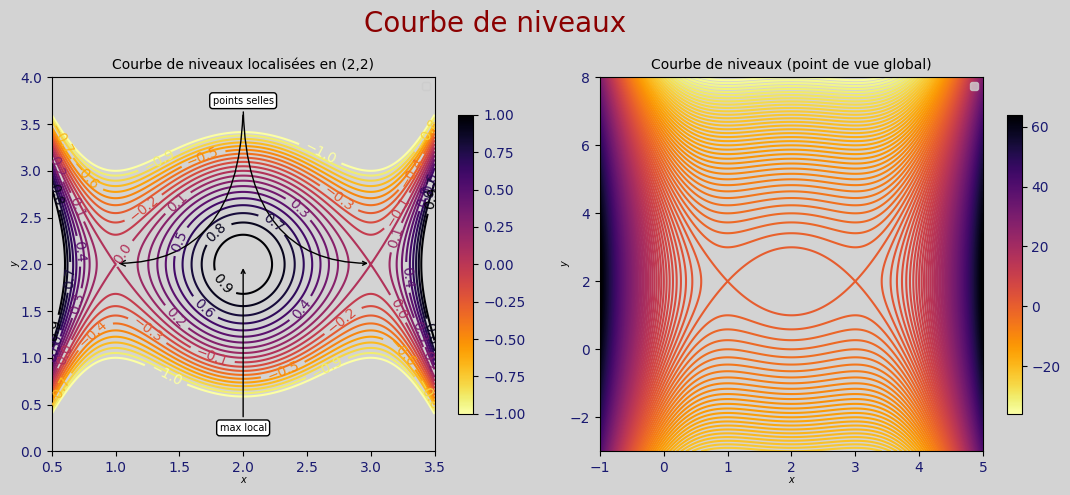

In [10]:
x = np.linspace(0.5, 3.5, 300) #abscisses
y = np.linspace(0, 4, 300) #ordonnées

# Création numérique des courbes de niveaux
xx, yy = np.meshgrid(x, y) 
ff = (xx - 3)**2 * (xx - 1)**2 - (yy - 2)**2

# NIVEAU GLOBAL
xglob = np.linspace(-1, 5, 1000)
yglob = np.linspace(-3, 8, 1000)

xxglob, yyglob = np.meshgrid(xglob, yglob)
ffglob = (xxglob - 3)**2 * (xxglob - 1)**2 - (yyglob - 2)**2

#Création de la fenêtre graphique
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))

#thème couleur
cmap = plt.get_cmap('inferno')

#mise en place des courbes de niveaux 
contour1 = ax[0].contour(xx, yy, ff, np.arange(-1, 1, 0.1), cmap=cmap.reversed())
ax[0].clabel(contour1, inline=1, fontsize=10)

#on normalise les couleurs par rapport à nos données
norm1 = Normalize(vmin=ff.min(), vmax=ff.max())

#et on l'applique au thème couleur de notre graphique
sm1 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm1)

sm1.set_array([]) 

#on définit les limites de couelur de l'objet (s'applique aussi aux valeurs extrêmes de la légende)
sm1.set_clim(-1, 1)
ax[0].set_title(f'Courbe de niveaux localisées en (2,2)',size = 10)
fig.colorbar(sm1, ax=ax[0], shrink=0.8)#shrink définit la "taille" de la légende

#annotations :
ax[0].annotate('max local', xy=(2,2-0.01), xytext=(2,0.25),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))

ax[0].annotate('', xy=(1,2+0.01), xytext=(2,3.75),va="center", ha="left",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[0].annotate('points selles', xy=(3,2+0.01), xytext=(2,3.75),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))



contour2 = ax[1].contour(xxglob, yyglob, ffglob, np.arange(ffglob.min(), ffglob.max(), 1), cmap=cmap.reversed())
norm2 = Normalize(vmin=ffglob.min(), vmax=ffglob.max())
sm2 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm2)
sm2.set_array([])
sm2.set_clim(ffglob.min(), ffglob.max())
ax[1].set_title(f'Courbe de niveaux (point de vue global)',size = 10)
fig.colorbar(sm2, ax=ax[1], shrink=0.8)

fcg.mon_themev2(fig=fig,Ax=ax,titre="Courbe de niveaux",titre_fontsize=20,
                xlabelsize = 7,ylabelsize=7,
            show_grid=False,show_legende_a_droite=False,
            hauteur_graph = 1,marge_droite_graph=1.1)

plt.show()

### Graphique 3d optimisation libre :

c:\Users\hugoc\Desktop\website_quarto\sections\projets\Dossier_Hugo_Romain\Mes_fonctions\Fonction_graphique\Fonction_graphique.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return fig.tight_layout(rect=(0, 0.0, marge_droite_graph, hauteur_graph))


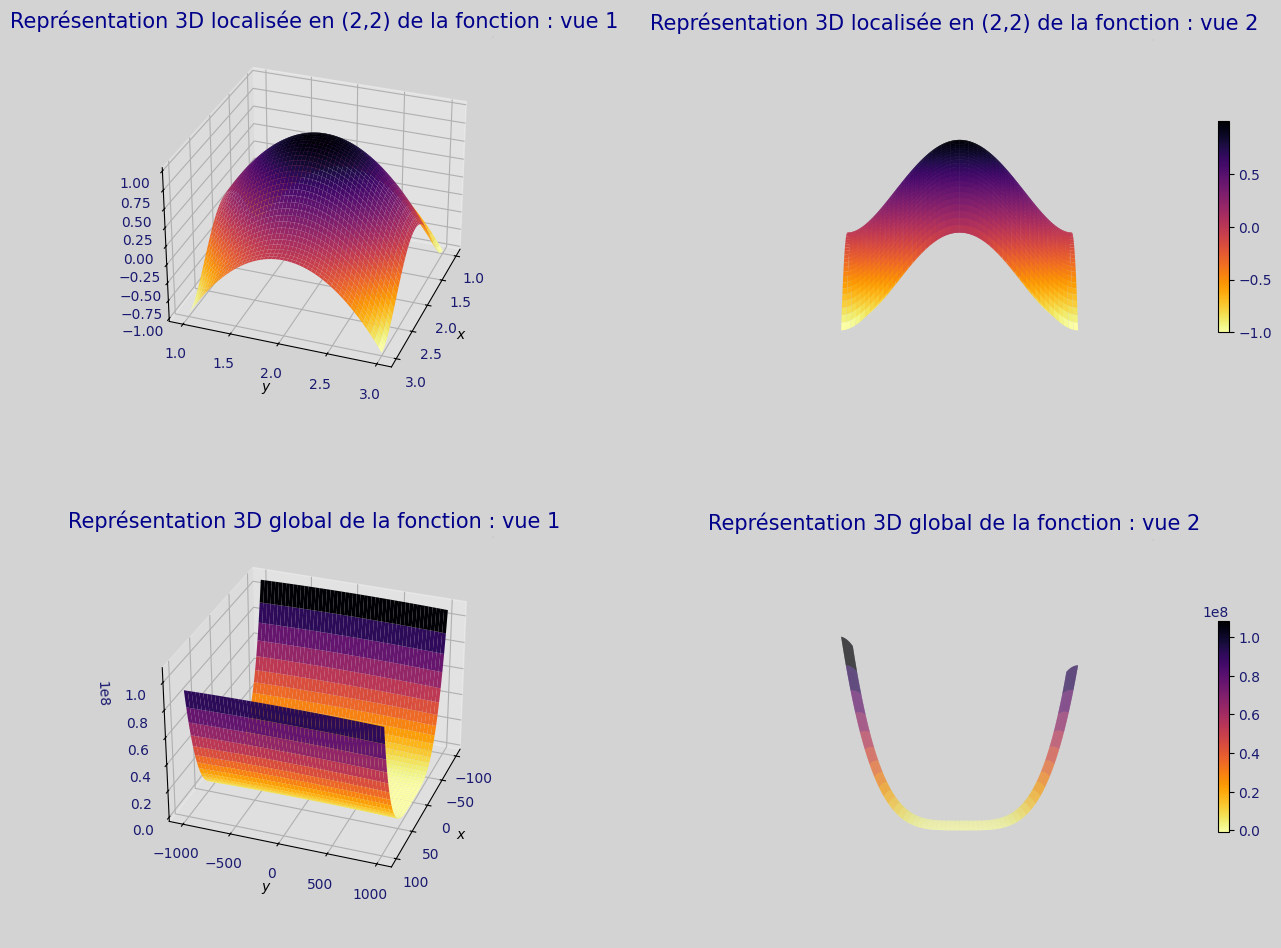

In [11]:
# Définition de la grille
# NIVEAU LOCAL
x = np.linspace(1.0, 3.0, 2000)
y = np.linspace(1.0, 3.0, 2000)
xx, yy = np.meshgrid(x, y)
ff = (xx - 3)**2 * (xx - 1)**2 - (yy - 2)**2


# NIVEAU GLOBAL
x_glob = np.linspace(-100.0, 100.0, 2000)
y_glob = np.linspace(-1000.0, 1000.0, 2000)
xx_glob, yy_glob = np.meshgrid(x_glob, y_glob)
ffglob = (xx_glob - 3)**2 * (xx_glob - 1)**2 - (yy_glob - 2)**2

# Création de la figure
fig = plt.figure(figsize=(15, 10))  # Réglez la taille de la figure principale ici

# Création des points de vue
ax1 = fig.add_axes([0.1, 0.5725, 0.3, 0.4], projection='3d')  # [left, bottom, width, height]
ax2 = fig.add_axes([0.55, 0.55, 0.4, 0.4], projection='3d')
ax3 = fig.add_axes([0.1, 0.0725, 0.3, 0.4], projection='3d')
ax4 = fig.add_axes([0.55, 0.05, 0.4, 0.4], projection='3d')

cmap = plt.get_cmap('inferno')

surf1 = ax1.plot_surface(xx, yy, ff, cmap=cmap.reversed())
surf2 = ax2.plot_surface(xx, yy, ff, cmap=cmap.reversed())
surf3 = ax3.plot_surface(xx_glob, yy_glob, ffglob, cmap=cmap.reversed())
surf4 = ax4.plot_surface(xx_glob, yy_glob, ffglob, cmap=cmap.reversed())

ax1.view_init(30, 20)
ax2.view_init(0, 270)
ax3.view_init(30, 20)
ax4.view_init(0, 270)

# Titres des sous-graphiques
ax1.set_title('Représentation 3D localisée en (2,2) de la fonction : vue 1', size=15, color='darkblue')
ax2.set_title('Représentation 3D localisée en (2,2) de la fonction : vue 2', size=15, color='darkblue')
ax3.set_title('Représentation 3D global de la fonction : vue 1', size=15, color='darkblue')
ax4.set_title('Représentation 3D global de la fonction : vue 2', size=15, color='darkblue')

# Création de la légende
norm = Normalize(vmin=ff.min(), vmax=ff.max())
sm = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm)
sm.set_array([])
sm.set_clim(ff.min(), ff.max())

norm2 = Normalize(vmin=ffglob.min(), vmax=ffglob.max())
sm2 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm2)
sm2.set_array([])
sm2.set_clim(ffglob.min(), ffglob.max())

# Ajout de la légende de couleur
fig.colorbar(sm, ax=[ax1, ax2], shrink=0.5)  # Réglez la taille ici
fig.colorbar(sm2, ax=[ax3, ax4], shrink=0.5)  # Réglez la taille ici
ax = [ax1,ax2,ax3,ax4]

ax2.axis('off')
ax4.axis('off')
fcg.mon_themev2(fig = fig, Ax=ax,
              titre="",
              marge_droite_graph=1.1,hauteur_graph=0.5,
            titre_fontsize=20,legend_fontsize=0,show_legende_a_droite=False)



plt.show()

### Graphique courbes de niveaux sous contraintes :

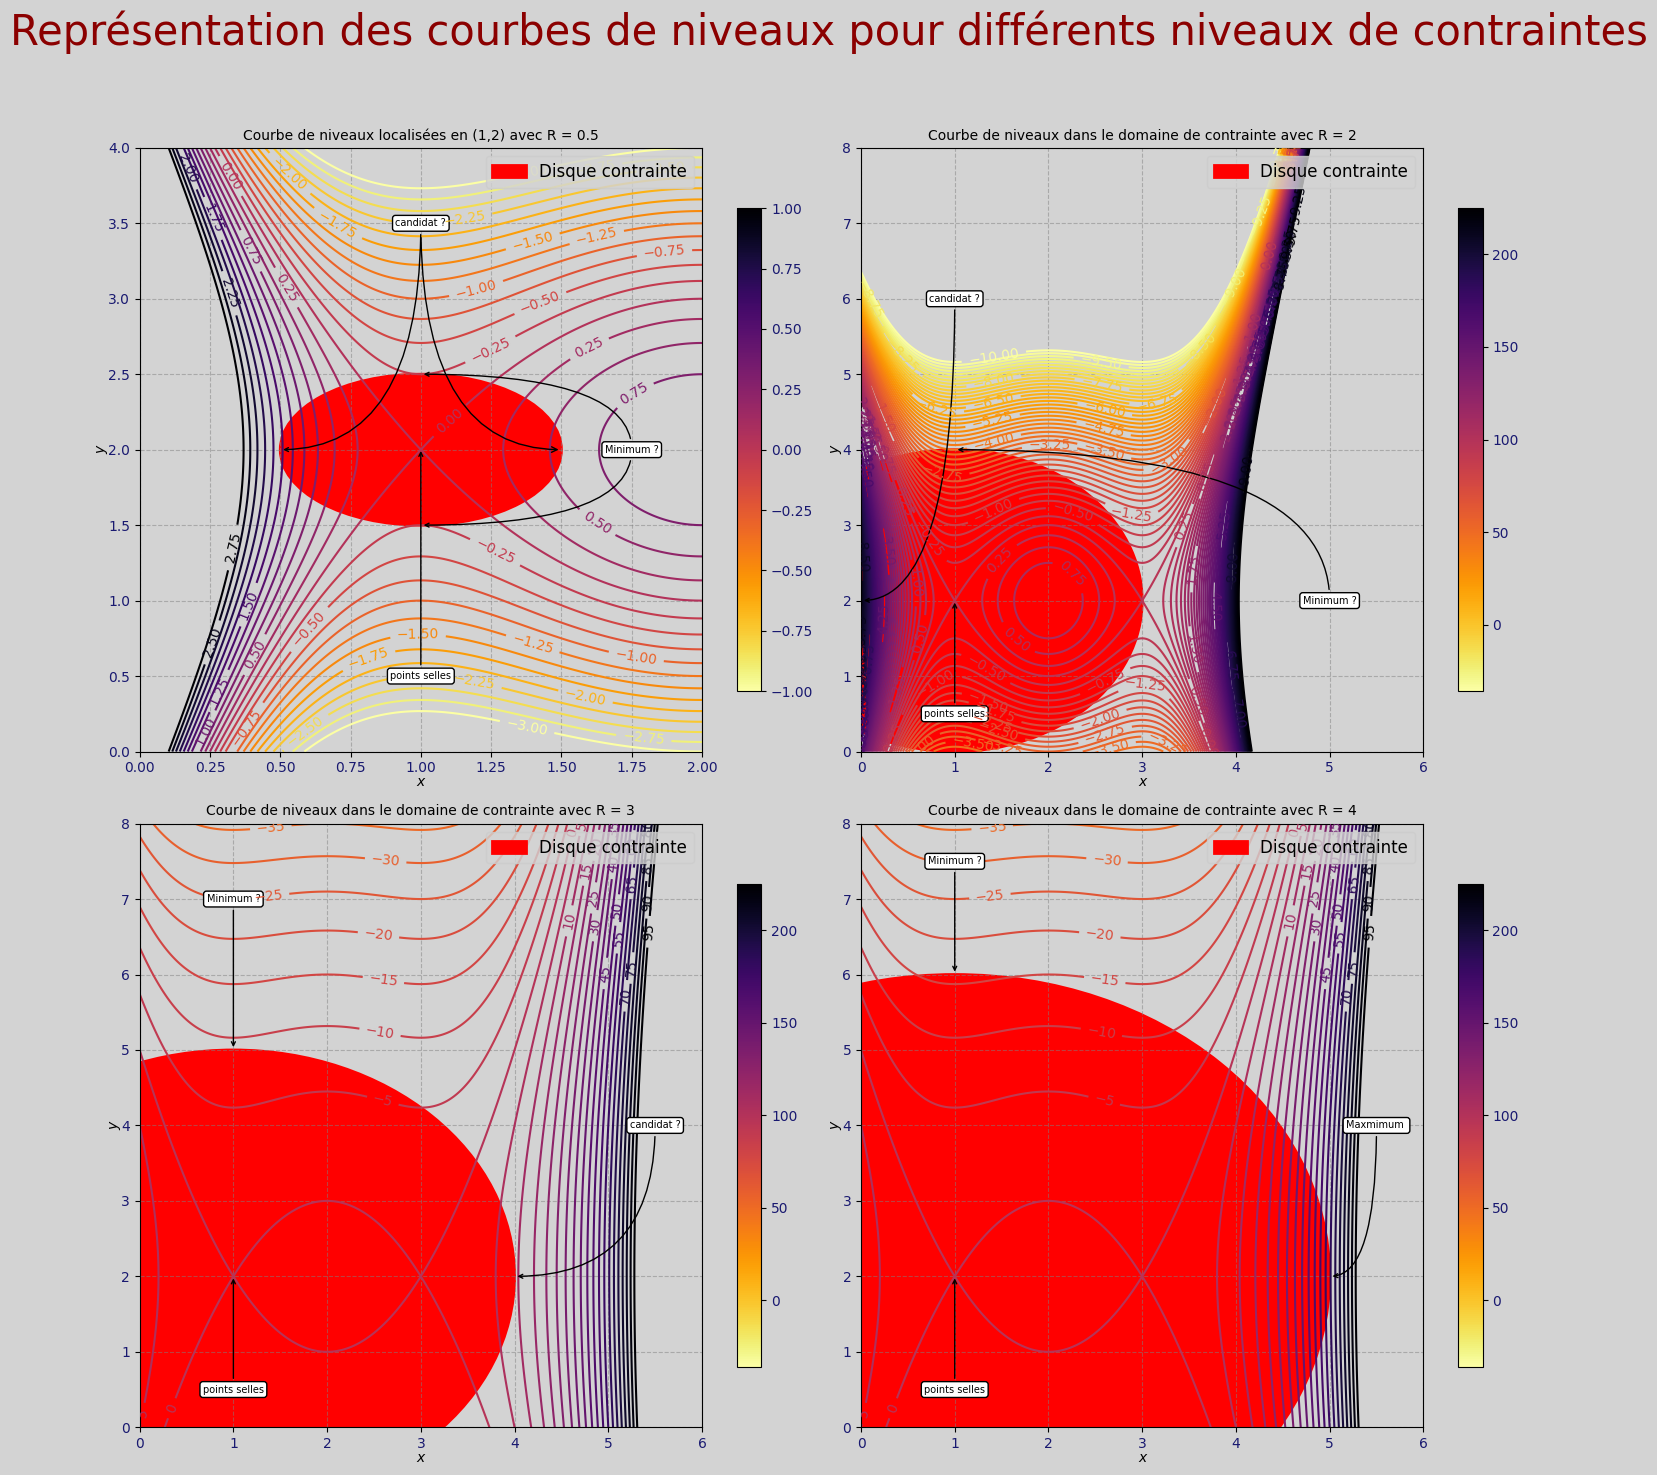

In [12]:





x = np.linspace(0, 2, 300) #abscisses
y = np.linspace(0, 4, 300) #ordonnées

# Création numérique des courbes de niveaux
xx, yy = np.meshgrid(x, y) 
ff = (xx - 3)**2 * (xx - 1)**2 - (yy - 2)**2

# NIVEAU GLOBAL
xglob = np.linspace(0, 6, 1000)
yglob = np.linspace(0, 8, 1000)

xxglob, yyglob = np.meshgrid(xglob, yglob)
ffglob = (xxglob - 3)**2 * (xxglob - 1)**2 - (yyglob - 2)**2

#Disque

R_Disque = [0.5,2,3,4]
centre_disque = (1,2)

#Création de la fenêtre graphique
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(15, 15))

#thème couleur
cmap = plt.get_cmap('inferno')

#mise en place des courbes de niveaux 
contour1 = ax[0,0].contour(xx, yy, ff, np.arange(-3, 3, 0.25), cmap=cmap.reversed())
cercle_1 = plt.Circle(centre_disque,R_Disque[0],fill = 'orange',color = 'red',linestyle = '-',lw = 2,label = 'Disque contrainte')
ax[0,0].add_artist(cercle_1)


ax[0,0].clabel(contour1, inline=1, fontsize=10)
#on normalise les couleurs par rapport à nos données
norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
#et on l'applique au thème couleur de notre graphique
sm1 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm1)
sm1.set_array([]) #commande nécessaire (essaye de la comprendre)
#on définit les limites de couelur de l'objet (s'applique aussi aux valeurs extrêmes de la légende)
sm1.set_clim(-1, 1)
ax[0,0].set_title(f'Courbe de niveaux localisées en (1,2) avec R = 0.5',size = 10)
fig.colorbar(sm1, ax=ax[0,0], shrink=0.8)#shrink définit la "taille" de la légende

#annotations :
ax[0,0].annotate('candidat ?', xy=(0.5,2), xytext=(1,3.5),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))

ax[0,0].annotate('', xy=(1.5,2), xytext=(1,3.5),va="center", ha="left",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[0,0].annotate('points selles', xy=(1,2+0.01), xytext=(1,0.5),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[0,0].annotate('Minimum ?', xy=(1,2.5), xytext=(1.75,2),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[0,0].annotate('', xy=(1,1.5), xytext=(1.75,2),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

#mise en place des courbes de niveaux 
contour2 = ax[0,1].contour(xxglob, yyglob, ffglob, np.arange(-10, 10, 0.25), cmap=cmap.reversed())
cercle_2 = plt.Circle(centre_disque,R_Disque[1],fill = 'orange',color = 'red',linestyle = '-',lw = 2,label = 'Disque contrainte')
ax[0,1].add_artist(cercle_2)


ax[0,1].clabel(contour2, inline=1, fontsize=10)
#on normalise les couleurs par rapport à nos données
norm2 = Normalize(vmin=ffglob.min(), vmax=ffglob.max())
#et on l'applique au thème couleur de notre graphique
sm2 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm2)
sm2.set_array([]) #commande nécessaire (essaye de la comprendre)
#on définit les limites de couelur de l'objet (s'applique aussi aux valeurs extrêmes de la légende)
sm2.set_clim(ffglob.min(), ffglob.max())
ax[0,1].set_title(f'Courbe de niveaux dans le domaine de contrainte avec R = 2',size = 10)
fig.colorbar(sm2, ax=ax[0,1], shrink=0.8)#shrink définit la "taille" de la légende

#annotations :
ax[0,1].annotate('candidat ?', xy=(0,2), xytext=(1,6),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))


ax[0,1].annotate('points selles', xy=(1,2+0.01), xytext=(1,0.5),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[0,1].annotate('Minimum ?', xy=(1,4), xytext=(5,2),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))



#mise en place des courbes de niveaux 
contour3 = ax[1,0].contour(xxglob, yyglob, ffglob, np.arange(-100, 100, 5), cmap=cmap.reversed())
cercle_3 = plt.Circle(centre_disque,R_Disque[2],fill = 'orange',color = 'red',linestyle = '-',lw = 2,label = 'Disque contrainte')
ax[1,0].add_artist(cercle_3)


ax[1,0].clabel(contour3, inline=1, fontsize=10)
#on normalise les couleurs par rapport à nos données
norm3 = Normalize(vmin=ffglob.min(), vmax=ffglob.max())
#et on l'applique au thème couleur de notre graphique
sm3 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm3)
sm3.set_array([]) #commande nécessaire (essaye de la comprendre)
#on définit les limites de couelur de l'objet (s'applique aussi aux valeurs extrêmes de la légende)
sm3.set_clim(ffglob.min(), ffglob.max())
ax[1,0].set_title(f'Courbe de niveaux dans le domaine de contrainte avec R = 3',size = 10)
fig.colorbar(sm3, ax=ax[1,0], shrink=0.8)#shrink définit la "taille" de la légende

#annotations :
ax[1,0].annotate('candidat ?', xy=(4,2), xytext=(5.5,4),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))



ax[1,0].annotate('points selles', xy=(1,2+0.01), xytext=(1,0.5),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[1,0].annotate('Minimum ?', xy=(1,5), xytext=(1,7),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))





#mise en place des courbes de niveaux 
contour4 = ax[1,1].contour(xxglob, yyglob, ffglob, np.arange(-100, 100, 5), cmap=cmap.reversed())
cercle_4 = plt.Circle(centre_disque,R_Disque[3],fill = 'orange',color = 'red',linestyle = '-',lw = 2,label = 'Disque contrainte')
ax[1,1].add_artist(cercle_4)


ax[1,1].clabel(contour4, inline=1, fontsize=10)
#on normalise les couleurs par rapport à nos données
norm4 = Normalize(vmin=ffglob.min(), vmax=ffglob.max())
#et on l'applique au thème couleur de notre graphique
sm4 = plt.cm.ScalarMappable(cmap=cmap.reversed(), norm=norm4)
sm4.set_array([]) 
#on définit les limites de couelur de l'objet (s'applique aussi aux valeurs extrêmes de la légende)
sm4.set_clim(ffglob.min(), ffglob.max())
ax[1,1].set_title(f'Courbe de niveaux dans le domaine de contrainte avec R = 4',size = 10)
fig.colorbar(sm4, ax=ax[1,1], shrink=0.8)#shrink définit la "taille" de la légende

#annotations :
ax[1,1].annotate('Maxmimum ', xy=(5,2), xytext=(5.5,4),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))



ax[1,1].annotate('points selles', xy=(1,2+0.01), xytext=(1,0.5),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))

ax[1,1].annotate('Minimum ?', xy=(1,6), xytext=(1,7.5),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))


for i in range(2):
    for j in range(2):
        fcg.mon_theme(fig=fig, Ax=ax[i, j],show_legende_a_droite=False,show_grid=True,
        hauteur_graph = 0.95,marge_droite_graph = 1,titre_fontsize = 30,xlabelsize = 10,ylabelsize = 10,
        titre = "Représentation des courbes de niveaux pour différents niveaux de contraintes",
        legend_fontsize = 12)


plt.show()




###  Graphique f(x,y) en tout R


<>:126: SyntaxWarning: invalid escape sequence '\l'
<>:129: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\s'
<>:134: SyntaxWarning: invalid escape sequence '\s'
<>:126: SyntaxWarning: invalid escape sequence '\l'
<>:129: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\s'
<>:134: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hugoc\AppData\Local\Temp\ipykernel_26360\920089269.py:126: SyntaxWarning: invalid escape sequence '\l'
  Ax.plot(R_values, expr1crit_values, label='$f(1, -R+2)$ si $R \leq 2$ \n $f(1,0)$ sinon')
C:\Users\hugoc\AppData\Local\Temp\ipykernel_26360\920089269.py:129: SyntaxWarning: invalid escape sequence '\l'
  Ax.plot(R_values, expr4crit_values, label='$f(-R+1, 2)$ si $R \leq 1$ \n $f(0,2)$ sinon')
C:\Users\hugoc\AppData\Local\Temp\ipykernel_26360\920089269.py:133: SyntaxWarning: invalid escape sequence '\s'
  Ax.plot(R_values, expr5crit_values, label='$f(-\sqrt{R^2 -4}+1

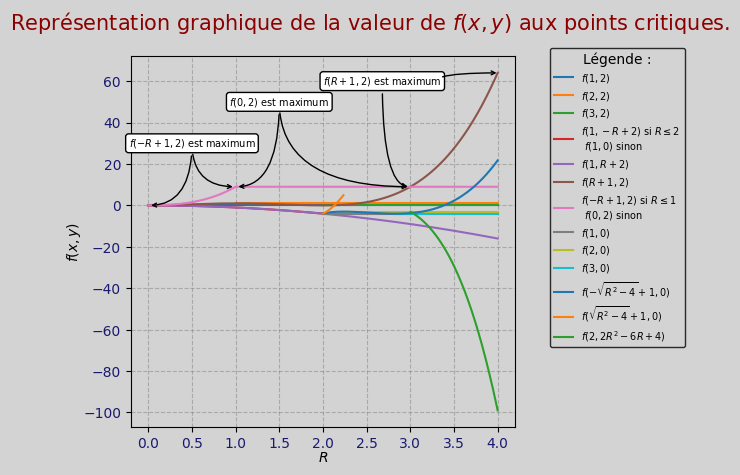

In [13]:
# Comparaison pour tout R


import sympy as sym
import numpy as np
import matplotlib.pyplot as plt


R, x, y = sym.symbols('R x y')


R_values = np.linspace(0, 4, 1000)  


f = (x-3)**2 * (x-1)**2 - (y-2)**2 



def calculer_f12(R):
    f12 = f.subs({x: 1, y: 2})
    return f12

def calculer_f22(R):
    if R < 1:
        return None
    else:
        f22 = f.subs({x: 2, y: 2})
    return f22

def calculer_f32(R):
    if R < 2:
        return None
    else:
        f32 = f.subs({x: 3, y: 2})
    return f32

def calculer_f10(R):
    if R < 2:
        return None
    else:
        f10 = f.subs({x: 1, y: 0})
    return f10

def calculer_f20(R):
    if R < sym.sqrt(5):
        return None
    else:
        f20 = f.subs({x: 2, y: 0})
    return f20

def calculer_f30(R):
    if R < 2*sym.sqrt(2):
        return None
    else:
        f30 = f.subs({x: 3, y: 0})
    return f30


def calculer_f1crit(R):
    if R < 2:
        f1crit = -(R**2)
    else:
        f1crit = -(2**2)
    return f1crit

def calculer_f2crit(R):
    f2crit = -(R**2)
    return f2crit

def calculer_f3crit(R):
    f3crit = R**2 * (R - 2)**2
    return f3crit

def calculer_f4crit(R):
    if R <= 1:
        f4crit = R**2 * (-R - 2)**2
    else:
        f4crit = 1**2 * (-1 - 2)**2
    return f4crit


def calculer_f5crit(R):
    if R >= 2:
        f5crit = f.subs({x:sym.sqrt(R**2 -4)+1,y:0})
    else:
        return None
    return f5crit


def calculer_f6crit(R):
    if R >= 2 and R <= sym.sqrt(5):
        f6crit = f.subs({x:-sym.sqrt(R**2 -4)+1,y:0})
    else:
        return None
    return f6crit


def calculer_f7crit(R):
    if R >= 3:
        f7crit = f.subs({x:2,y:2*R**2 -6*R + 4})
    else:
        return None
    return f7crit




expr12_values = [calculer_f12(r) for r in R_values]
expr22_values = [calculer_f22(r) for r in R_values]
expr32_values = [calculer_f32(r) for r in R_values]
expr10_values = [calculer_f10(r) for r in R_values]
expr20_values = [calculer_f20(r) for r in R_values]
expr30_values = [calculer_f30(r) for r in R_values]
expr1crit_values = [calculer_f1crit(r) for r in R_values]
expr2crit_values = [calculer_f2crit(r) for r in R_values]
expr3crit_values = [calculer_f3crit(r) for r in R_values]
expr4crit_values = [calculer_f4crit(r) for r in R_values]
expr5crit_values = [calculer_f5crit(r) for r in R_values]
expr6crit_values = [calculer_f6crit(r) for r in R_values]
expr7crit_values = [calculer_f7crit(r) for r in R_values]

fig,Ax = plt.subplots(ncols=1,nrows=1)
Ax.plot(R_values, expr12_values, label='$f(1,2)$')
Ax.plot(R_values, expr22_values, label='$f(2,2)$')
Ax.plot(R_values, expr32_values, label='$f(3,2)$')
Ax.plot(R_values, expr1crit_values, label='$f(1, -R+2)$ si $R \leq 2$ \n $f(1,0)$ sinon')
Ax.plot(R_values, expr2crit_values, label='$f(1, R+2)$')
Ax.plot(R_values, expr3crit_values, label='$f(R+1, 2)$')
Ax.plot(R_values, expr4crit_values, label='$f(-R+1, 2)$ si $R \leq 1$ \n $f(0,2)$ sinon')
Ax.plot(R_values, expr10_values, label='$f(1,0)$')
Ax.plot(R_values, expr20_values, label='$f(2,0)$')
Ax.plot(R_values, expr30_values, label='$f(3,0)$')
Ax.plot(R_values, expr5crit_values, label='$f(-\sqrt{R^2 -4}+1, 0)$')
Ax.plot(R_values, expr6crit_values, label='$f(\sqrt{R^2 -4}+1, 0)$')
Ax.plot(R_values, expr7crit_values, label='$f(2, 2R^2 -6R +4)$')

Ax.annotate('$f(-R+1,2)$ est maximum', xy=(0,0), xytext=(0.5,30),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))
Ax.annotate('', xy=(1,9), xytext=(0.5,30),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))

Ax.annotate('$f(0,2)$ est maximum', xy=(1,9), xytext=(1.5,50),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))
Ax.annotate('', xy=(3,9), xytext=(1.5,50),fontsize = 7,va="center", ha="center",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3'))


Ax.annotate('$f(R+1,2)$ est maximum', xy=(3,9), xytext=(2,60),fontsize = 7,va="center", ha="left",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))
Ax.annotate('', xy=(4.02,64), xytext=(3.3,60),fontsize = 7,va="center", ha="left",
                  bbox=dict(boxstyle="round", fc="w",facecolor ="lightgrey"),
                  arrowprops=dict(arrowstyle="->",connectionstyle='angle3',color='black'))


fcg.mon_theme(fig = fig, Ax = Ax,show_legende_a_droite=True,
              titre="Représentation graphique de la valeur de $f(x,y)$ aux points critiques.",
            ylabel = '$f(x,y)$',xlabel = "$R$",
            marge_droite_graph = 0.75,show_grid =True  )

# Trouvez l'expression la plus grande

# Introduction au problème d'optimisation

## Partie 1 : Optimisation libre

$$ \underset{x,y}{\text{Argmax}} \ f(x,y)=(x-3)^2(x-1)^2-(y-2)^2 $$

## Partie 2 : Optimisation sous contraintes

Détermination du maximum de $f$ dans $(\mathcal{D}_R \cap \left(\mathbb{R}_+ \times \mathbb{R}_+\right))$ en fonction du paramètre $(R > 0)$. (Une analyse graphique est fortement appréciée)


On a le problème de maximisation suivant :

$$
\begin{aligned}
& \underset{x,y}{\text{Max}} & & f(x,y) = (x-3)^2(x-1)^2 - (y-2)^2 \\
& \text{sous les contraintes} & & \begin{cases}
R^2 \geq (x-1)^2 + (y-2)^2 \\
x \geq 0 \\
y \geq 0
\end{cases}
\end{aligned}
$$

## Partie 3 : Optimisation sous contraintes

Soit maintenant la fonction $g(x,y,z)=(x-3)^2(x-1)^2-(y-2)^2+\lambda z^2$ et $\Theta_R=\mathcal{D}_R\times [-5,5]$

Déterminer le maximum de $g_\lambda$ dans $\Theta_R \cap \left(\mathbb{R}_+\times \mathbb{R}_+\times \mathbb{R}_+\right).$ en fonction des paramètres $R>0$ et $\lambda \in \mathbb{R}$.
(On utlisera du calcul numérique pour différentes valeurs des paramètres et on comparera les résultats).

# Etude de l'exercice

## Partie 1 : Optimisation libre


On a le problème de maximisation suivant:

$$ \underset{x,y}{\text{Argmax}} \ f(x,y)=(x-3)^2(x-1)^2-(y-2)^2 $$



Nous allons tout d'abord visualiser les courbes de niveaux :

![texte](opti_python_file/imgs/Courbe_de_niveaux_libre.png)

In [14]:
ordre_symboles = [x,y]
Gradient,pc,Hessienne,H, mineurs,resultat,mineurs_tp = opti_libre_sympy(f,ordre_symboles= ordre_symboles)
sym.init_printing(order='lex')
for i in Gradient,pc,Hessienne,H, mineurs,resultat,mineurs_tp:
    display(i)
for i in H:
    for j in nature_libre(i):
        display(j)
f_val = []
for i in pc :
    f_val.append(f.subs({x:i[0],y:i[1]}))

⎡       2                    2          ⎤
⎢(x - 3) ⋅(2⋅x - 2) + (x - 1) ⋅(2⋅x - 6)⎥
⎢                                       ⎥
⎣               -2⋅y + 4                ⎦

⎡         2            2                            ⎤
⎢2⋅(x - 3)  + 2⋅(x - 1)  + 2⋅(2⋅x - 6)⋅(2⋅x - 2)  0 ⎥
⎢                                                   ⎥
⎣                       0                         -2⎦

⎡⎡8  0 ⎤  ⎡-4  0 ⎤  ⎡8  0 ⎤⎤
⎢⎢     ⎥, ⎢      ⎥, ⎢     ⎥⎥
⎣⎣0  -2⎦  ⎣0   -2⎦  ⎣0  -2⎦⎦

["C'est un point selle", "C'est un maximum local", "C'est un point selle"]

⎡8  0 ⎤
⎢     ⎥
⎣0  -2⎦

'Ce point critique est un point selle.'

⎡-4  0 ⎤
⎢      ⎥
⎣0   -2⎦

"C'est un maximum local"

⎡8  0 ⎤
⎢     ⎥
⎣0  -2⎦

'Ce point critique est un point selle.'

Le gradient de  $f$ est :

$$\nabla \begin{bmatrix}
(x-3)^2 \cdot (2x-2) + (x-1)^2 \cdot (2x-6) \\
-2y + 4
\end{bmatrix}$$

dont les points critiques sont :

$$
(1,2) \\
(2,2) \\
(3,2) \\
$$


- La hessienne au point $(1,2)$ est :

$$H(1,2) = \begin{bmatrix}
8 & 0 \\
0 & -2
\end{bmatrix}$$ 

Les mineurs de cette matrice sont $m1 = 8$ et $m2 = -16$, un mineur d'ordre pair étant négatif, on peut affirmer que le point $(1,2)$ est un point selle.


- La hessienne au point $(2,2)$ est :

$$H(2,2) = \begin{bmatrix}
-4 & 0 \\
0 & -2
\end{bmatrix}$$

Les mineurs de cette matrice sont $m1 = -4$ et $m2 = 8$, les mineurs de cette matrice remplissent donc les conditions suffisantes d'ordre 2, donc $(2,2)$ est un maximum local 



- La hessienne au point $(3,2)$ est :

$$H(3,2) = \begin{bmatrix}
8 & 0 \\
0 & -2
\end{bmatrix}$$

Les mineurs de cette matrice sont $m1 = 8$ et $m2 = -16$, un mineur d'ordre pair étant négatif, on peut affirmer que le point $(3,2)$ est un point selle

Nous pouvons donc conclure que :
- $f$ admet un maximum local en $(2,2)$ qui est de $f(2,2) = 1$
- et deux points selles $(1,2)$ et $(3,2)$ où $f(1,2) = f(3,2) = 0$

Cette visualisation 3d est une bonne manière de visualiser la localité de ce maximum :

![Visualisation 3d de la fonction](opti_python_file/imgs/vis_3d_opti_libre.png)

## 2ème partie

Détermination du maximum de $f$ dans $(\mathcal{D}_R \cap \left(\mathbb{R}_+ \times \mathbb{R}_+\right))$ en fonction du paramètre $(R > 0)$. (Une analyse graphique est fortement appréciée)

On a le problème de maximisation suivant:

$$
\begin{aligned}
& \underset{x,y}{\text{Max}} & & f(x,y) = (x-3)^2(x-1)^2 - (y-2)^2 \\
& \text{sous les contraintes} & & \begin{cases}
R^2 \geq (x-1)^2 + (y-2)^2 \\
x \geq 0 \\
y \geq 0
\end{cases}
\end{aligned}
$$

Nous pouvons déjà commencer par observer les courbes de niveaux pour plusieurs valeurs de R:

![texte](opti_python_file/imgs/Courbe_de_niveaux_contraintes.png)



Nous pouvons réécrire ce problème ainsi :

$$
\begin{aligned}
& \underset{x,y,\lambda}{\text{Max}} & & \mathcal{L}(x,y,\lambda) = (x - 3)^2 (x - 1)^2 - (y - 2)^2 - \lambda( -R^2 + (x - 1)^2 + (y - 2)^2) \\
& \text{sous les contraintes} & & \begin{cases}
x \geq 0 \\
y \geq 0
\end{cases}
\end{aligned}
$$


In [16]:
x,y,W,w1,w2,R = sym.symbols('x y W w1 w2 R',real = True) #symboles
f = (x-3)**2 * (x-1)**2 - (y-2)**2 #fonction à maximiser
D = (x - 1)**2 + (y - 2)**2 - R**2 #contrainte égalité disque


#Contrainte du disque
Disque = sym.Rel((x - 1)**2 + (y - 2)**2,R**2,'<=')

#Contraintes de positivité
x_pos = sym.Rel(x,0,'>=')
y_pos = sym.Rel(y,0,'>=')

#Lagrangien

L = f-W*D

ordre_symboles = [W,x,y,R]

gradient_KKT,pc_KKT,hessienne_KKT,hessienne_pc_KKT = resolution_Ndim_KKT(L,par=[3],ordre_symboles=ordre_symboles)

for i in gradient_KKT,pc_KKT,hessienne_KKT,hessienne_pc_KKT:
    display(i)

⎡                 ⎛ 2          2          2⎞               ⎤
⎢               W⋅⎝R  - (x - 1)  - (y - 2) ⎠               ⎥
⎢                                                          ⎥
⎢  ⎛                      2                    2          ⎞⎥
⎢x⋅⎝-W⋅(2⋅x - 2) + (x - 3) ⋅(2⋅x - 2) + (x - 1) ⋅(2⋅x - 6)⎠⎥
⎢                                                          ⎥
⎣                y⋅(-W⋅(2⋅y - 4) - 2⋅y + 4)                ⎦

⎡   0                             -2⋅x + 2                         -2⋅y + 4⎤
⎢                                                                          ⎥
⎢                          2            2                                  ⎥
⎢-2⋅x + 2  -2⋅W + 2⋅(x - 3)  + 2⋅(x - 1)  + 2⋅(2⋅x - 6)⋅(2⋅x - 2)     0    ⎥
⎢                                                                          ⎥
⎣-2⋅y + 4                            0                             -2⋅W - 2⎦

⎡                                                                              ↪
⎢                                                                              ↪
⎢⎡                        ________⎤  ⎡                          ________⎤      ↪
⎢⎢                       ╱  2     ⎥  ⎢                         ╱  2     ⎥      ↪
⎢⎢      0        2   2⋅╲╱  R  - 1 ⎥  ⎢      0         2   -2⋅╲╱  R  - 1 ⎥  ⎡ 0 ↪
⎢⎢                                ⎥  ⎢                                  ⎥  ⎢   ↪
⎢⎢      2        46        0      ⎥, ⎢      2         46        0       ⎥, ⎢ 0 ↪
⎢⎢                                ⎥  ⎢                                  ⎥  ⎢   ↪
⎢⎢     ________                   ⎥  ⎢      ________                    ⎥  ⎣2⋅ ↪
⎢⎢    ╱  2                        ⎥  ⎢     ╱  2                         ⎥      ↪
⎢⎣2⋅╲╱  R  - 1   0         0      ⎦  ⎣-2⋅╲╱  R  - 1   0         0       ⎦      ↪
⎣                                                                              ↪

↪                          

En dérivant le lagrangien et en utilisant la méthode de Ken-tucker, nous obtenons le gradient suivant :

$$\nabla \begin{bmatrix}
x \cdot (-W(2x-2) + (x-3)^2 \cdot (2x-2) + (x-1)^2 \cdot (2x-6)) \\
y \cdot (-W(2y-4) - 2y + 4) \\
\lambda \cdot (R^2 - (x-1)^2 - (y-2)^2)
\end{bmatrix}$$

dont les points critiques $(\lambda,x,y)$ sont :

- $(-1, 0, -\sqrt{R^2 - 1} + 2)$ ; $\lambda = -1$, ce n'est donc pas un candidat au max
- $(-1, 0, \sqrt{R^2 - 1} + 2)$ ; $\lambda = -1$, ce n'est donc pas un candidat au max
- $(-1, 1, -R + 2)$ si $R \geq 2$ ; $\lambda = -1$, ce n'est donc pas un candidat au max 
- $(-1, 1, R + 2)$ ; $\lambda = -1$, ce n'est donc pas un candidat au max
- $(0, 0, 0)$ si $R \geq \sqrt5$
- $(0, 0, 2)$ si $R \geq 1$
- $(0, 1, 0)$ si $R \geq 2$
- $(0, 1, 2)$ on a vu lors de l'optimisation libre que ce point était un point selle
- $(0, 2, 0)$ si $R \geq \sqrt5$
- $(0, 2, 2)$ si $R \geq 1$, on a vu lors de l'optimisation libre que ce point était un maximum local
- $(0, 3, 0)$ si $R \geq 2 \cdot\sqrt2$
- $(0, 3, 2)$ si $R \geq 2$ on a vu lors de l'optimisation libre que ce point était un point selle
- $(2(R - 2)(R - 1), R + 1, 2)$ candidat au max si $R \in ]0,1[\cup]2,+\infty[$
- $(2(R + 1)(R + 2), -R + 1, 2)$ si $R \leq 1$
- $(2R^2 - 6\sqrt{R^2 - 4} - 4, \sqrt{R^2 - 4} + 1, 0)$ si $R \geq 2$
- $(2R^2 + 6\sqrt{R^2 - 4} - 4, -\sqrt{R^2 - 4} + 1, 0)$ si $R \in [2,\sqrt5]$







-   $(1, -R+2, -1)$ impossible car $(x,y) \geq (0,0)$  

-   $(1, R+2, -1)$ impossible car $(x,y) \geq (0,0)$  

-   $(R+1, 2, 2R^2 - 6R+4)$ si $R \geq 3$

-   $(-R+1, 2, 2R^2 + 6R+4)$ candidat au max si $R \leq 1$









Nous avons donc différentes situations selon la valeur de R :

1) $R \in ]0,1[$

In [17]:


x,y,W,w1,w2,R = sym.symbols('x y W w1 w2 R',real = True) #symboles
f = (x-3)**2 * (x-1)**2 - (y-2)**2 #fonction à maximiser
D = (x - 1)**2 + (y - 2)**2 - R**2 #contrainte égalité disque


#Contrainte du disque
Disque = sym.Rel((x - 1)**2 + (y - 2)**2,R**2,'<=')

#Contraintes de positivité
x_pos = sym.Rel(x,0,'>=')
y_pos = sym.Rel(y,0,'>=')

#Lagrangien

L = f-W*D

ordre_symboles = [W,x,y,R]


v = 0.5
candidat_max = []
val_f_pc_sans_conclu = []
pc_sans_conclu_valide = []
pc_sans_conclu_max = []
pc_sans_conclu_hors_domaine = []
pc_sature = []
hessienne_sature = []
pc_non_sature = []
hessienne_non_sature = []
pc_invalide = []

ordre_symboles = [W,x,y,R]

gradient_KKT,pc_KKT,hessienne_KKT,hessienne_pc_KKT = resolution_Ndim_KKT(L,par=[3],valpar=[v],ordre_symboles=ordre_symboles)
for i,j in zip(pc_KKT,range(0,len(pc_KKT))):
    if i[1] < 0 or i[2] <0:
        pc_invalide.append(i)
    elif i[1]==0 or i[2]==0:
        #display(i)
        #display("La méthode n'est pas concluante")
        #display(f.subs({x:i[1],y:i[2]}))
        #display(Disque)
        if Disque.subs({x:i[1],y:i[2],R:v}):
            pc_sans_conclu_valide.append(i)
            val_f_pc_sans_conclu.append(f.subs({x:i[1],y:i[2]}))
        else: 
            pc_sans_conclu_hors_domaine.append(i)
    elif i[0]==0:
        pc_non_sature.append(i)
        hessienne_non_sature.append(hessienne_pc_KKT[j][1:3,1:3])
        #display("La contrainte n'est pas saturée")
        #display(hessienne_pc_KKT[j][1:3,1:3])
    else:
        pc_sature.append(i)
        hessienne_sature.append(hessienne_pc_KKT[j])
        #display("La contrainte est saturée")
        #display(hessienne_pc_KKT[j])



for i,j in zip(pc_non_sature,range(0,len(pc_non_sature))) :
    H,mineurs, resultat = nature_libre(hessienne_non_sature[j])
    for index, i in enumerate(resultat):
        if i == "C'est un maximum local":
            candidat_max.append(pc_non_sature[index])
    



mineurs, mineurs_voulue, resultat = nature_sous_contraintes(hessienne_sature,nb_contrainte=1,nb_variable=2)
for index, i in enumerate(resultat):
    if i == "C'est un maximum local":
        candidat_max.append(pc_sature[index])



if val_f_pc_sans_conclu != [] :
    valeur_maximale = max(val_f_pc_sans_conclu)
    for i in pc_sans_conclu_valide:
        if f.subs({x:i[1],y:i[2]}) == valeur_maximale:
            pc_sans_conclu_max.append(i)
    for i in pc_sans_conclu_max:
        candidat_max.append(i)

f_max = {}
for i in candidat_max:
    f_max[i] = f.subs({x:i[1],y:i[2]})

# Trouvez la clé (point) correspondant à la valeur maximale
point_max = max(f_max, key=f_max.get)
valeur_max = f_max[point_max]
texte = f"Pour R ={v}, la valeur maximale de f est {valeur_max} atteinte au point ({point_max[1]},{point_max[2]})"

display(texte)

'Pour R =0.5, la valeur maximale de f est 9.00000000000000 atteinte au point (0.0,2.00000000000000)'

2) $R = 1$

In [18]:
resolution_total(v=1)[4]

'Pour R =1, la valeur maximale de f est 9 atteinte au point (0,2)'

2) $R \in ]1,2[$

In [19]:
resolution_total(v=1.5)[4]

'Pour R =1.5, la valeur maximale de f est 9.00000000000000 atteinte au point (0.0,2.00000000000000)'

4) $R = 2$

In [20]:
resolution_total(v=2)[4]

'Pour R =2, la valeur maximale de f est 9 atteinte au point (0,2)'

5) $R \in ]2, \sqrt5[$

In [21]:
resolution_total(v=2.1)[4]

'Pour R =2.1, la valeur maximale de f est 9.00000000000000 atteinte au point (0.0,2.00000000000000)'

6) $R = \sqrt5$

In [22]:
resolution_total(v=sym.sqrt(5))[4]

'Pour R =sqrt(5), la valeur maximale de f est 9 atteinte au point (0,2)'

7) $R \in ]\sqrt5, 2\cdot\sqrt2[$

In [23]:
resolution_total(v=2.5)[4]

'Pour R =2.5, la valeur maximale de f est 9.00000000000000 atteinte au point (0.0,2.00000000000000)'

8) $R = 2\cdot\sqrt2$

In [24]:
resolution_total(v=2*sym.sqrt(2))[4]

'Pour R =2*sqrt(2), la valeur maximale de f est 9 atteinte au point (0,2)'

9) $R \in ]2\cdot\sqrt2, 3[$

In [25]:
resolution_total(v=2.95)[4]

'Pour R =2.95, la valeur maximale de f est 9.00000000000000 atteinte au point (0.0,2.00000000000000)'

10) $R = 3$

In [26]:
resolution_total(v=3)[4]

'Pour R =3, la valeur maximale de f est 9 atteinte au point (4,2)'

11) $R \geq 3$

In [27]:
resolution_total(v=5)[4]

'Pour R =5, la valeur maximale de f est 225 atteinte au point (6,2)'

Observons le comportement de la fonction aux différents points candidats : 

![texte](opti_python_file/imgs/val_f_pourtout_R.png)

Ces différents résultats nous permettent de conclure que :


$$f(x,y)=(x-3)^2(x-1)^2-(y-2)^2 \\ $$

sous les contraintes suivantes :

$$R^2 \geq (x-1)^2 + (y-2)^2 \\ 
x \geq 0 \\ 
y \geq 0 \\ 
R \gt 0$$

atteint son maximum au point $(-R +1,2)$ lorsque $R \leq 1$ $\\$
Sa valeur à ce point est $f(-R+1,2) = R^2 \cdot(-R-2)^2$

atteint son maximum au point $(0,2)$ lorsque $R \in [1,3[ \\$
Sa valeur à ce point est $f(0,2) = 9 $

atteint son maximum aux points $(4,2)$ et $(0,2)$  lorsque $R = 3$ $\\$
Sa valeur à ce point est $f(R+1,2) = R^2 \cdot(R-2)^2  = 9$

atteint son maximum au point $(R+1,2)$ lorsque $R \gt 3$ $\\$
Sa valeur à ce point est $f(R+1,2) = R^2 \cdot(R-2)^2 $


## 3 ème partie :

Soit maintenant la fonction $g(x,y,z)=(x-3)^2(x-1)^2-(y-2)^2+\lambda z^2$ et $\Theta_R=\mathcal{D}_R\times [-5,5]$

Déterminer le maximum de $g_\lambda$ dans $\Theta_R \cap \left(\mathbb{R}_+\times \mathbb{R}_+\times \mathbb{R}_+\right).$ en fonction des paramètres $R>0$ et $\lambda \in \mathbb{R}$.
(On utlisera du calcul numérique pour différentes valeurs des paramètres et on comparera les résultats).

Afin de répondre à cette question, nous allons utiliser le package scypy et sa fonction minimize :

In [28]:
x,y,z,W,V,R = sym.symbols('x y z W V R',real = True)

def f(X,*args):
    x,y,z = X
    W = args[0]
    return -((x - 3) ** 2 * (x - 1) ** 2 - (y - 2) ** 2 + W*z**2)


def g(X,*args):
    R = args[0] 
    return args[0]**2  -((X[0]-1)**2 + (X[1]-2)**2)

Rayons = [RR for RR in [0.5,1,2,2.5,3,5]]
lambda_valeur = [-5,-1,0, 1, 5]
cond_initiale = [(0.,0.,0.),(0.5,0.5,0.5),(1.,1.,1.),(2.,2.,2.),(2.5,2.5,2.5),(3.,3.,3.),(5.,5.,5.),(10.,10.,10.)]

for R in Rayons:
    for v in lambda_valeur:
        val = []
        results = []
        point_max = []
        result_retenu = []
        for x_init in cond_initiale:
            cons = {'type':'ineq','fun':g,'args':[R]}
            bnd = ((0,None),(0,None),(0,5))


            result = so.minimize(f, x0=x_init,
                        constraints=cons,
                        bounds=bnd,
                        args=v)
            results.append(result)
            val.append(-result.fun)
            point_max.append(result.x)
        valeur_max = round(max(val),5)
        for res in results:
            if round(res.fun,5) == -valeur_max:
                result_retenu.append(res)
        result_x_arrondi = []
        for res in result_retenu:
            result_x_arrondi.append([round(i,2)for i in res.x])
        print(f'Un Rayon de R={R} donne le(s) point(s),\n{result_x_arrondi},\npour lambda={v}.')
        print('La valeur de f à ce(s) point(s) est de {:f}\n'.format(-result.fun),'\n\n\n\n----------------------------------------------------------------------------------------')


Un Rayon de R=0.5 donne le(s) point(s),
[[0.5, 2.0, 0.0], [0.5, 2.0, 0.0], [0.5, 2.0, 0.0]],
pour lambda=-5.
La valeur de f à ce(s) point(s) est de 0.562500
 



----------------------------------------------------------------------------------------
Un Rayon de R=0.5 donne le(s) point(s),
[[0.5, 2.0, 0.0], [0.5, 2.0, 0.0], [0.5, 2.0, 0.0], [0.5, 2.0, 0.0]],
pour lambda=-1.
La valeur de f à ce(s) point(s) est de 1.562500
 



----------------------------------------------------------------------------------------
Un Rayon de R=0.5 donne le(s) point(s),
[[0.5, 2.0, 0.0], [0.5, 2.0, 0.5], [0.5, 2.0, 5.0], [0.5, 2.0, 5.0]],
pour lambda=0.
La valeur de f à ce(s) point(s) est de 1.562500
 



----------------------------------------------------------------------------------------
Un Rayon de R=0.5 donne le(s) point(s),
[[0.5, 2.0, 5.0], [0.5, 2.0, 5.0], [0.5, 2.0, 5.0], [0.5, 2.0, 5.0], [0.5, 2.0, 5.0]],
pour lambda=1.
La valeur de f à ce(s) point(s) est de 26.562500
 



------------------

Les résultats fournis par ces commandes sont différents en fonction de la valeur des paramètres R et $\lambda$ :

### - $R \leq 1$ 
La valeur de $f$ est maximale et égale à $R^2\cdot(-R^2 -1)+\lambda z$ au point :
- $(-R+1,2,z)$ avec 

$\begin{equation}
z = \begin{cases}
    0 & \text{si } \lambda < 0 \\
    \text{toute valeur de } z & \text{si } \lambda = 0 \\
    5 & \text{sinon}
\end{cases}
\end{equation}$

### - $R \in ]1,3[$ 

La valeur de $f$ est maximale et égale à 9+$\lambda z$ au point :
- $(0,2,z)$ avec 

$\begin{equation}
z = \begin{cases}
    0 & \text{si } \lambda < 0 \\
    \text{toute valeur de } z & \text{si } \lambda = 0 \\
    5 & \text{sinon}
\end{cases}
\end{equation}$

### - $R = 3$ 

La valeur de $f$ est maximale et égale à $9+\lambda z$ aux points :
- $(0,2,z)$ et $(R+1,2,z)$ avec 

$\begin{equation}
z = \begin{cases}
    0 & \text{si } \lambda < 0 \\
    \text{toute valeur de } z & \text{si } \lambda = 0 \\
    5 & \text{sinon}
\end{cases}
\end{equation}$

### - $R \gt 3$

La valeur de $f$ est maximale et égale à $R^2\cdot(R^2 -1)+\lambda z$ au point :

- $(R+1,2,z)$ avec 

$\begin{equation}
z = \begin{cases}
    0 & \text{si } \lambda < 0 \\
    \text{toute valeur de } z & \text{si } \lambda = 0 \\
    5 & \text{sinon}
\end{cases}
\end{equation}$